In [1]:
!pip install -U "langchain>=1.3.14"

In [2]:
!pip install  langchain-openai langchain-community langgraph python-dotenv langchain-mcp-adapters langchain-chroma chromadb pypdf

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

False

In [4]:
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

In [5]:
from langchain.chat_models import init_chat_model

model = init_chat_model('openai:gpt-5-mini')
model.invoke('Hi')
print("Cinebot's Brain is connected")

Cinebot's Brain is connected


In [6]:
print("hello")

hello


In [7]:
from langchain_core.tools import tool
import sqlite3


In [8]:

@tool
def save_trip_demo(user_id: str, destination: str) -> str:
    """Save a trip to the database. Irreversible without manual cleanup."""
    return f"Trip to {destination} saved for {user_id}."  # standing in for a real DB write

In [9]:
from langchain.agents import create_agent

from langchain.agents.middleware import SummarizationMiddleware


agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[save_trip_demo],
    middleware=[
        SummarizationMiddleware(
            model = 'gpt-5.4-mini',
            trigger = ('token',4000),
            keep =('messages',10),
        )
    ])

ValueError: Unsupported context size type token for trigger.

Summarization is text-oriented context compression. It does not resize, downsample, or otherwise compress image/audio/video payloads. Recent messages retained by keep still include their original multimodal blocks, while older multimodal messages that are summarized are represented only by the generated text summary. For image-heavy applications, store media in a filesystem or object store and pass URLs or file references through message history.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def your_read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def your_send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="gpt-5.5",
    tools=[your_read_email_tool, your_send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "your_send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "your_read_email_tool": False,
            }
        ),
    ],
)

In [ ]:
config = {'configurable':{"thread_id":"hitl"}}

result =agent.invoke({"messages": [("user", "Send an email to my manager on mayank953ai@gmail.com, asking for a leave")]}, config=config)

In [ ]:
result

{'messages': [HumanMessage(content='Send an email to my manager on mayank953ai@gmail.com, asking for a leave', additional_kwargs={}, response_metadata={}, id='53f81a0b-c1d4-47a5-b38e-98087628e08e'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 180, 'total_tokens': 312, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 51, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.5-2026-04-23', 'system_fingerprint': None, 'id': 'chatcmpl-EAS6lMyMeoU5aJQndl3uxzB5bBKZq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fdf6f-32e1-76a3-8649-6ea3dd447abc-0', tool_calls=[{'name': 'your_send_email_tool', 'args': {'recipient': 'mayank953ai@gmail.com', 'subject': 'Leave Request', 'body': 'De

```
User
  │
  │ "Send an email asking for leave"
  ▼
LLM
  │
  │ decides to call
  ▼
your_send_email_tool
  │
  │ requires approval
  ▼
INTERRUPT
  │
  ├── approve → send email
  ├── edit    → modify tool arguments
  └── reject  → don't send
```

In [ ]:
# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain.tools import tool as tool_rt, ToolRuntime

In [ ]:
# --- LangGraph (checkpointing, resuming) ---
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

In [ ]:
from langchain.agents.middleware import (
    SummarizationMiddleware,
    HumanInTheLoopMiddleware,
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
    ModelFallbackMiddleware,
    PIIMiddleware,
    TodoListMiddleware,
    LLMToolSelectorMiddleware,
    ToolRetryMiddleware,
    ModelRetryMiddleware,
    LLMToolEmulator,
    ContextEditingMiddleware,
    ClearToolUsesEdit,
)

# Please start from here

Defining Tools for my Cinebot - Dummy as of now but ofcourse will be real as we have seen in last class.

In [13]:
@tool
def check_showtimes(movie_title: str) -> str:
    """Check available showtimes for a movie at the cinema."""
    fake_showtimes = {
        "interstellar": "7:00 PM and 10:15 PM",
        "dune part two": "9:30 PM only",
        "oppenheimer": "Sold out for tonight",
    }
    return fake_showtimes.get(movie_title.lower(), "No showtimes found for that title.")



In [14]:

@tool
def book_seats(movie_title: str, seat_count: int) -> str:
    """Book seats for a movie. Irreversible once confirmed."""
    return f"Booked {seat_count} seat(s) for {movie_title}."


In [15]:
@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."


In [16]:
@tool
def check_order_status(booking_id: str) -> str:
    """Check the status of an existing booking."""
    return f"Booking {booking_id}: confirmed, 2 seats, Interstellar, 7:00 PM."


In [17]:
@tool
def get_refund_policy() -> str:
    """Get the cinema's refund policy -- exact wording, not to be paraphrased."""
    return "Refunds available up to 2 hours before showtime. No refunds after that."

In [18]:

@tool
def lookup_seat_map(movie_title: str, seat_number: str) -> str:
    """Look up a specific seat -- fails if the seat number format is wrong."""
    if not seat_number or not seat_number[0].isalpha():
        raise ValueError(f"Malformed seat number '{seat_number}' -- expected a letter+number like 'A12'.")
    return f"Seat {seat_number} for {movie_title}: available."


In [19]:
cinebot_tools = [check_showtimes, book_seats, cancel_booking, check_order_status, get_refund_policy, lookup_seat_map]


In [20]:
def pretty_print_messages(result):
    for i, message in enumerate(result.get("messages", []), 1):
        print(f"\n{'=' * 80}")
        print(f"Message {i}: {message.__class__.__name__}")
        print("=" * 80)

        # Basic message information
        print(f"ID: {getattr(message, 'id', None)}")

        # Message content
        content = getattr(message, "content", "")
        if content:
            print("\nContent:")
            print(content)

        # Tool calls
        tool_calls = getattr(message, "tool_calls", None)
        if tool_calls:
            print("\nTool Calls:")
            for tool in tool_calls:
                print(f"  • {tool['name']}")
                print(f"    Args: {tool['args']}")
                print(f"    ID:   {tool['id']}")

        # Tool message information
        tool_call_id = getattr(message, "tool_call_id", None)
        if tool_call_id:
            print(f"\nTool Call ID: {tool_call_id}")

        # Summarization information
        additional_kwargs = getattr(message, "additional_kwargs", {})
        if additional_kwargs.get("lc_source"):
            print(f"\nSource: {additional_kwargs['lc_source']}")

    print(f"\n{'=' * 80}")
    print("END OF MESSAGE HISTORY")
    print("=" * 80)

# Summarization Middleware

In [ ]:
plz add comment for token if > this summarise previous messages and keep last 3 messages only . help us to memorise it

In [ ]:
summarizing_agent = create_agent(
    model="gpt-5.4-mini",
    tools=cinebot_tools,
    middleware=[
        SummarizationMiddleware(
            model="gpt-5.4-mini",
            trigger=("tokens", 300),
            keep=("messages", 1),
        )
    ],
)



In [ ]:
print(summarizing_agent.invoke({"messages": [("user", "Hi I am mayank ")]}))

In [ ]:
print(summarizing_agent.invoke({"messages": [("user", "Who am I ? ")]}))

{
    'messages': [
        HumanMessage(
            content='Who am I ? ',
            additional_kwargs={},
            response_metadata={},
            id='e9baedf4-2ff9-40a8-908e-8c766ac7e74e'
        ),
        AIMessage(
            content='I don’t know who you are from this chat alone.\n\nIf you want, I can help you figure it out by
asking a few quick questions, like:\n- your name or nickname\n- where you’re from\n- what you’re trying to do 
here\n\nOr if you meant “Who am I?” in a philosophical sense, I can help with that too.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 77,
                    'prompt_tokens': 281,
                    'total_tokens': 358,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.4-mini-2026-03-17',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAUPTLi0Vtjmc0EqzPlCnH2dzFTmg',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fdff6-39ad-7d20-a01a-bd9dae10c611-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 281,
                'output_tokens': 77,
                'total_tokens': 358,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

In [ ]:
result = summarizing_agent.invoke({"messages": [("user", "Is Interstellar showing tonight? also please make sure that you book me a ticket, refund me if it is not available,also share the refund policy for me to go through, also check my order status for book_1234")]})

In [ ]:
pretty_print_messages(result)


Message 1: HumanMessage
ID: 0e49eee6-eff5-4e57-bd4e-55c7777fe417

Content:
Here is a summary of the conversation to date:

## SESSION INTENT

The user wants to know whether *Interstellar* is showing tonight, wants a ticket booked if available, wants a refund if it is not available, asks to be shown the refund policy, and wants the order status checked for `book_1234`.

## SUMMARY

The only user request so far is a multi-part cinema/support task:
- Check whether *Interstellar* is showing tonight.
- If available, book a ticket.
- If unavailable, refund the user.
- Share the refund policy for review.
- Check the status of order `book_1234`.

No actions have been completed yet, and no decisions have been made. There is no additional context about location, theater, showtime preferences, payment method, or booking details.

## ARTIFACTS

None

## NEXT STEPS

- Check tonight’s availability for *Interstellar*.
- If available, proceed with ticket booking.
- If unavailable, initiate refund wor

# HITL (Human in the Loop)

In [ ]:
guarded_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={"cancel_booking": {"allowed_decisions": ["approve", "edit", "reject", "respond"]}}
        ),
    ],
    checkpointer=InMemorySaver(),  # REQUIRED -- HITL needs to pause and later resume
)

config = {'configurable':{'thread_id':'hitl-demo-live'}}

In [ ]:
print(guarded_agent.invoke({"messages": [("user", "I am Mayank . ")]}),config=config)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
print(summarizing_agent.invoke({"messages": [("user", "Who am I ? ")]}))

In [ ]:
result = guarded_agent.invoke({"messages": [("user", "Please cancel booking BK1042")]}, config=config)

In [ ]:
from rich import print

In [ ]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Please cancel booking BK1042',
            additional_kwargs={},
            response_metadata={},
            id='6e00b765-ec48-4ad0-b027-0666d9e9b600'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 90,
                    'prompt_tokens': 282,
                    'total_tokens': 372,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EATSjJfo5pVgFeJZsgRTPVn0hBTqi',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fdfbe-a461-7712-aa01-081629d179b9-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'BK1042'},
                    'id': 'call_YBVgSDGMWgVMw8nhV0uiipCP',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 282,
                'output_tokens': 90,
                'total_tokens': 372,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        )
    ],
    '__interrupt__': [
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'cancel_booking',
                        'args': {'booking_id': 'BK1042'},
                        'description': "Tool execution requires approval\n\nTool: cancel_booking\nArgs: 
{'booking_id': 'BK1042'}"
                    }
                ],
                'review_configs': [
                    {
                        'action_name': 'cancel_booking',
                        'allowed_decisions': ['approve', 'edit', 'reject', 'respond']
                    }
                ]
            },
            id='95785cb3f8a6d71008f6d3b328aac5f1'
        )
    ]
}

In [ ]:
state = guarded_agent.get_state(config)

In [ ]:
state # Please paste it into Chat GPT and ask it to explain the same or Mayank GPT

StateSnapshot(values={'messages': [HumanMessage(content='Please cancel booking BK1042', additional_kwargs={}, response_metadata={}, id='6e00b765-ec48-4ad0-b027-0666d9e9b600'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 282, 'total_tokens': 372, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EATSjJfo5pVgFeJZsgRTPVn0hBTqi', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fdfbe-a461-7712-aa01-081629d179b9-0', tool_calls=[{'name': 'cancel_booking', 'args': {'booking_id': 'BK1042'}, 'id': 'call_YBVgSDGMWgVMw8nhV0uiipCP', 'type': 'tool_call'}], invalid_tool_calls=

In [ ]:
print(state.tasks[0])

PregelTask(
    id='f1019ca0-1a1e-90e8-46fa-baa84742df27',
    name='HumanInTheLoopMiddleware.after_model',
    path=('__pregel_pull', 'HumanInTheLoopMiddleware.after_model'),
    error=None,
    interrupts=(
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'cancel_booking',
                        'args': {'booking_id': 'BK1042'},
                        'description': "Tool execution requires approval\n\nTool: cancel_booking\nArgs: 
{'booking_id': 'BK1042'}"
                    }
                ],
                'review_configs': [
                    {
                        'action_name': 'cancel_booking',
                        'allowed_decisions': ['approve', 'edit', 'reject', 'respond']
                    }
                ]
            },
            id='95785cb3f8a6d71008f6d3b328aac5f1'
        ),
    ),
    state=None,
    result=None
)

In [ ]:
resumed_result = guarded_agent.invoke(Command(resume={"decisions":[{"type":"approve"}]}),config=config)

In [ ]:
print(resumed_result)

{
    'messages': [
        HumanMessage(
            content='Please cancel booking BK1042',
            additional_kwargs={},
            response_metadata={},
            id='6e00b765-ec48-4ad0-b027-0666d9e9b600'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 90,
                    'prompt_tokens': 282,
                    'total_tokens': 372,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EATSjJfo5pVgFeJZsgRTPVn0hBTqi',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fdfbe-a461-7712-aa01-081629d179b9-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'BK1042'},
                    'id': 'call_YBVgSDGMWgVMw8nhV0uiipCP',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 282,
                'output_tokens': 90,
                'total_tokens': 372,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='Booking BK1042 cancelled.',
            name='cancel_booking',
            id='89984781-335f-4f33-a0bd-94320fd25e0c',
            tool_call_id='call_YBVgSDGMWgVMw8nhV0uiipCP'
        ),
        AIMessage(
            content='Done — booking BK1042 has been cancelled.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 13,
                    'prompt_tokens': 319,
                    'total_tokens': 332,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EATbk5gARpCNVNIykljNoYtliErnm',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fdfc7-2b3a-7a21-8a2d-530522dd1791-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 319,
                'output_tokens': 13,
                'total_tokens': 332,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

In [ ]:
state.next

('HumanInTheLoopMiddleware.after_model',)

In [ ]:
def run_interactive_hitl_demo(agent, config):
    """A genuinely interactive HITL loop -- ask out loud, type the answer, watch it apply live."""
    state = agent.get_state(config)
    if not state.next:
        print("Nothing is currently paused for approval.")
        return

    print("The agent wants to call a guarded tool. Choose a decision:")
    print("  1) approve  -- run it exactly as proposed")
    print("  2) edit     -- run it, but change the booking_id first")
    print("  3) reject   -- block it, with a reason sent back to the agent")
    print("  4) respond  -- answer a question instead of deciding on the action")

    choice = input("Type 1, 2, 3, or 4: ").strip()

    if choice == "1":
        decision = {"type": "approve"}
    elif choice == "2":
        new_id = input("New booking_id to use instead: ").strip()
        decision = {"type": "edit", "args": {"booking_id": new_id}}
    elif choice == "3":
        reason = input("Reason for rejecting: ").strip()
        decision = {"type": "reject", "message": reason}
    elif choice == "4":
        answer = input("Your response to the agent: ").strip()
        decision = {"type": "respond", "message": answer}
    else:
        print("Not a valid choice -- try again.")
        return

    resumed = agent.invoke(Command(resume={"decisions": [decision]}), config=config)
    print()
    print("Agent's final response:", resumed["messages"][-1].content)


In [ ]:
config = {'configurable':{'thread_id':'hitl-demo-live-2'}}

In [ ]:
guarded_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={"cancel_booking": {"allowed_decisions": ["approve", "edit", "reject", "respond"]}}
        ),
    ],
    checkpointer=InMemorySaver(),  # REQUIRED -- HITL needs to pause and later resume
)


In [ ]:
result = guarded_agent.invoke({"messages": [("user", "Please cancel booking BK1042")]}, config=config)

In [ ]:
run_interactive_hitl_demo(guarded_agent, config)

The agent wants to call a guarded tool. Choose a decision:

1) approve  -- run it exactly as proposed

2) edit     -- run it, but change the booking_id first

3) reject   -- block it, with a reason sent back to the agent

4) respond  -- answer a question instead of deciding on the action

Type 1, 2, 3, or 4: 3
Reason for rejecting: Don't want to cancel the same.


Agent's final response: I couldn’t cancel BK1042 — the system returned: “Don’t want to cancel the same.” That 
indicates the cancellation wasn’t accepted (possible reasons: the booking is already canceled, non‑cancellable, or 
the system blocked the request).

What would you like me to do next?
- I can check the booking status for BK1042.
- I can retrieve the cinema’s refund/cancellation policy.
- I can try canceling BK1042 again (confirm if you want me to retry).
- I can connect you with support for a manual review.

Tell me which option you prefer, or confirm if the booking ID is correct.

> ⚙️ **Code Walkthrough:** `Command(resume={"decisions": [...]})` is how you hand a decision
> back to an agent that's paused mid-run. The `decisions` list has one entry per interrupted
> tool call (usually just one). Each decision is a dict with a `"type"` key matching one of the
> four options, plus whatever extra data that type needs — `edit` needs new `args`, `reject` and
> `respond` need a `message`, `approve` needs nothing else.

# Model Call Limit

In [ ]:
call_limited_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),  # required for thread_limit to persist across calls
    middleware=[
        ModelCallLimitMiddleware( # low values taken just for example
            thread_limit=5,   # across the WHOLE conversation
            run_limit=2,       # per single .invoke() call
            exit_behavior="end",  # graceful stop, not an exception
        ),
    ],
)

In [ ]:
result = call_limited_agent.invoke(
    {"messages": [("user", "Can you tell me cinema's refund policy? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [ ]:
print(result)

{
    'messages': [
        HumanMessage(
            content="Can you tell me cinema's refund policy? ",
            additional_kwargs={},
            response_metadata={},
            id='48344212-11d7-42aa-a0e0-d49a97ac6141'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 85,
                    'prompt_tokens': 286,
                    'total_tokens': 371,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EATwQebUs9AydaNHo6UQhnNIAZrx2',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fdfda-bbff-7db1-91f8-a38e6f989ff2-0',
            tool_calls=[
                {
                    'name': 'get_refund_policy',
                    'args': {},
                    'id': 'call_ceGuXqVdTeUPuyVerdvweYyL',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 286,
                'output_tokens': 85,
                'total_tokens': 371,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='da0f1cc4-e10e-4164-a436-215094dea88e',
            tool_call_id='call_ceGuXqVdTeUPuyVerdvweYyL'
        ),
        AIMessage(
            content='Here’s the cinema’s exact refund policy (wording provided by the cinema):\n\n"Refunds 
available up to 2 hours before showtime. No refunds after that."',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 37,
                    'prompt_tokens': 331,
                    'total_tokens': 368,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EATwScKofJM6FmuDgd7ZT4AnkwqOC',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fdfda-c42f-7840-b3ed-967e2878e529-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 331,
                'output_tokens': 37,
                'total_tokens': 368,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

In [ ]:
result_invoke_2= call_limited_agent.invoke(
    {"messages": [("user", "cancel my booking B123? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

{'messages': [HumanMessage(content="Can you tell me cinema's refund policy? ", additional_kwargs={}, response_metadata={}, id='48344212-11d7-42aa-a0e0-d49a97ac6141'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 286, 'total_tokens': 371, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EATwQebUs9AydaNHo6UQhnNIAZrx2', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fdfda-bbff-7db1-91f8-a38e6f989ff2-0', tool_calls=[{'name': 'get_refund_policy', 'args': {}, 'id': 'call_ceGuXqVdTeUPuyVerdvweYyL', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input

In [ ]:
result_invoke3 = call_limited_agent.invoke(
    {"messages": [("user", "What all movies are being shown? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [ ]:
print(result_invoke3)

{
    'messages': [
        HumanMessage(
            content="Can you tell me cinema's refund policy? ",
            additional_kwargs={},
            response_metadata={},
            id='48344212-11d7-42aa-a0e0-d49a97ac6141'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 85,
                    'prompt_tokens': 286,
                    'total_tokens': 371,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EATwQebUs9AydaNHo6UQhnNIAZrx2',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fdfda-bbff-7db1-91f8-a38e6f989ff2-0',
            tool_calls=[
                {
                    'name': 'get_refund_policy',
                    'args': {},
                    'id': 'call_ceGuXqVdTeUPuyVerdvweYyL',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 286,
                'output_tokens': 85,
                'total_tokens': 371,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='da0f1cc4-e10e-4164-a436-215094dea88e',
            tool_call_id='call_ceGuXqVdTeUPuyVerdvweYyL'
        ),
        AIMessage(
            content='Here’s the cinema’s exact refund policy (wording provided by the cinema):\n\n"Refunds 
available up to 2 hours before showtime. No refunds after that."',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 37,
                    'prompt_tokens': 331,
                    'total_tokens': 368,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EATwScKofJM6FmuDgd7ZT4AnkwqOC',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fdfda-c42f-7840-b3ed-967e2878e529-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 331,
                'output_tokens': 37,
                'total_tokens': 368,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        HumanMessage(
            content='cancel my booking B123? ',
            additional_kwargs={},
            response_metadata={},
            id='70393038-51b6-

In [ ]:
result_invoke4 = call_limited_agent.invoke(
    {"messages": [("user", "Summarize my chat? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [ ]:
print(result_invoke4)

{
    'messages': [
        HumanMessage(
            content="Can you tell me cinema's refund policy? ",
            additional_kwargs={},
            response_metadata={},
            id='48344212-11d7-42aa-a0e0-d49a97ac6141'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 85,
                    'prompt_tokens': 286,
                    'total_tokens': 371,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EATwQebUs9AydaNHo6UQhnNIAZrx2',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fdfda-bbff-7db1-91f8-a38e6f989ff2-0',
            tool_calls=[
                {
                    'name': 'get_refund_policy',
                    'args': {},
                    'id': 'call_ceGuXqVdTeUPuyVerdvweYyL',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 286,
                'output_tokens': 85,
                'total_tokens': 371,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='da0f1cc4-e10e-4164-a436-215094dea88e',
            tool_call_id='call_ceGuXqVdTeUPuyVerdvweYyL'
        ),
        AIMessage(
            content='Here’s the cinema’s exact refund policy (wording provided by the cinema):\n\n"Refunds 
available up to 2 hours before showtime. No refunds after that."',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 37,
                    'prompt_tokens': 331,
                    'total_tokens': 368,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EATwScKofJM6FmuDgd7ZT4AnkwqOC',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fdfda-c42f-7840-b3ed-967e2878e529-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 331,
                'output_tokens': 37,
                'total_tokens': 368,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        HumanMessage(
            content='cancel my booking B123? ',
            additional_kwargs={},
            response_metadata={},
            id='70393038-51b6-

In [ ]:
from rich import print

# Model Fallback

In [ ]:
resilient_agent = create_agent(
    model="openai:gpt-5.5-haiku",     # primary, most capable
    tools=cinebot_tools,
)

Fallback chain: gpt-5.5 -> gpt-5-mini.

If the primary model call fails for any reason, this silently tries the next one.

In [ ]:
result = resilient_agent.invoke( {"messages": [("user", "Summarize my chat? ")]},)

NotFoundError: Error code: 404 - {'error': {'message': 'The model `gpt-5.5-haiku` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'param': None, 'code': 'model_not_found'}}

In [ ]:
resilient_agent = create_agent(
    model="openai:gpt-5.5-haiku",     # primary, most capable
    tools=cinebot_tools,
    middleware=[
        ModelFallbackMiddleware(
            "openai:gpt-5-mini",   # fallback -- cheaper, still OpenAI, needs no extra setup
            # "ollama:llama3.2",   # a further, fully-local last resort -- uncomment if you have
                                    # `pip install langchain-ollama` AND a local Ollama server running.
                                    # Left commented here so this cell runs with nothing beyond
                                    # what Setup already installed.
        ),
    ],
)
print("Fallback chain: gpt-5.5 -> gpt-5-mini.")
print("If the primary model call fails for any reason, this silently tries the next one.")

Fallback chain: gpt-5.5 -> gpt-5-mini.

If the primary model call fails for any reason, this silently tries the next one.

In [ ]:
result = resilient_agent.invoke( {"messages": [("user", "Summarize my chat? ")]},)

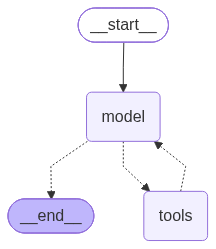

In [ ]:
from IPython.display import Image, display

graph = resilient_agent.get_graph()

display(Image(graph.draw_mermaid_png()))

In [ ]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Summarize my chat? ',
            additional_kwargs={},
            response_metadata={},
            id='7d57bc7a-0c03-4d13-a569-9d83685c3058'
        ),
        AIMessage(
            content='Do you mean this current conversation or a different chat (e.g., a transcript you have)? 
\n\nIf you mean this current session, here’s a very short summary:\n- System and developer instructions set up 
tools and behavior.\n- Several tool definitions for checking/showtimes, booking, cancelling, etc. were listed.\n- 
You asked: “Summarize my chat?”\n\nTell me which chat you want summarized (paste the transcript if it’s a different
one), and how you want the summary formatted:\n- TL;DR (1–2 lines)\n- Short bullets (3–6 points)\n- Detailed 
summary with action items and timestamps\n\nI can also extract highlights, questions, decisions, or draft an 
email/meeting note from the summary—which would you prefer?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 419,
                    'prompt_tokens': 283,
                    'total_tokens': 702,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 256,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAU2pSAu8fXqlxfjsbXvbHUOy9EOf',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fdfe0-cc48-70d2-986f-2b2c6253d88d-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 283,
                'output_tokens': 419,
                'total_tokens': 702,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 256}
            }
        )
    ]
}

# Tool Call Limit

In [ ]:
tool_limited_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),
    middleware=[
        ToolCallLimitMiddleware(run_limit=8),                              # global, this turn
        ToolCallLimitMiddleware(tool_name="cancel_booking", thread_limit=2),  # tighter, one tool, whole conversation
    ],
)

**Fraud detection in fintech:** a `wrap_tool_call`-style hook around every transaction-executing
tool, flagging or blocking based on velocity, amount, or pattern — exactly `CineBotComplianceMiddleware`'s
rate-limiting logic, aimed at fraud instead of booking abuse.

**Healthcare AI assistants:** `PIIMiddleware`-style redaction is often a genuine *legal*
requirement (HIPAA in the US) — the pattern from Part 2's PII sections isn't optional polish in
that industry, it's the difference between compliant and non-compliant software.

**Customer support platforms:** `HumanInTheLoopMiddleware`-style approval gates before any action
with real financial consequence (refunds, account changes) — the exact shape used to guard
`cancel_booking` here, used to guard a real refund tool there.

**Internal developer tools:** audit logging via `wrap_tool_call`, like Part 3's
`BookingAuditMiddleware`, is close to universal in any system where "who did what, when" needs a
real answer — compliance, debugging, or just accountability.

# 9th August

In [ ]:
tool_limited_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),
    middleware=[
        ToolCallLimitMiddleware(run_limit=8),                              # global, this turn
        ToolCallLimitMiddleware(tool_name="cancel_booking", thread_limit=2, run_limit=1),  # tighter, one tool, whole conversation
    ],
)

In [ ]:
config = {"configurable": {"thread_id": "tool-limit-demo"}}


In [ ]:
for i in range(3):
  result = tool_limited_agent.invoke({"messages": [("user", f"Please cancel my Booking with ID B{100+i} ? ")]}, config=config)
  print(result)

{
    'messages': [
        HumanMessage(
            content='Please cancel my Booking with ID B100 ? ',
            additional_kwargs={},
            response_metadata={},
            id='3e7d872f-fab3-4a1e-97c1-23b579a2cd2c'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 25,
                    'prompt_tokens': 286,
                    'total_tokens': 311,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAo32iCeFADDQRw8cdQb297cZjKWd',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fe476-1340-7af2-994a-debfeb9a1c8e-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'B100'},
                    'id': 'call_G8UhAZ7sVstXN3jMaiCJpWNd',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 286,
                'output_tokens': 25,
                'total_tokens': 311,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='Booking B100 cancelled.',
            name='cancel_booking',
            id='ef2f4406-0674-446c-84fa-85c60a6656ce',
            tool_call_id='call_G8UhAZ7sVstXN3jMaiCJpWNd'
        ),
        AIMessage(
            content='Done — your booking B100 has been cancelled.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 13,
                    'prompt_tokens': 321,
                    'total_tokens': 334,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAo34xOIc9nqucS9rn9UfJ87t2hjA',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fe476-1ef5-7070-a6ff-9d16143a6aca-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 321,
                'output_tokens': 13,
                'total_tokens': 334,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

{
    'messages': [
        HumanMessage(
            content='Please cancel my Booking with ID B100 ? ',
            additional_kwargs={},
            response_metadata={},
            id='3e7d872f-fab3-4a1e-97c1-23b579a2cd2c'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 25,
                    'prompt_tokens': 286,
                    'total_tokens': 311,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAo32iCeFADDQRw8cdQb297cZjKWd',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fe476-1340-7af2-994a-debfeb9a1c8e-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'B100'},
                    'id': 'call_G8UhAZ7sVstXN3jMaiCJpWNd',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 286,
                'output_tokens': 25,
                'total_tokens': 311,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='Booking B100 cancelled.',
            name='cancel_booking',
            id='ef2f4406-0674-446c-84fa-85c60a6656ce',
            tool_call_id='call_G8UhAZ7sVstXN3jMaiCJpWNd'
        ),
        AIMessage(
            content='Done — your booking B100 has been cancelled.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 13,
                    'prompt_tokens': 321,
                    'total_tokens': 334,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAo34xOIc9nqucS9rn9UfJ87t2hjA',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fe476-1ef5-7070-a6ff-9d16143a6aca-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 321,
                'output_tokens': 13,
                'total_tokens': 334,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        HumanMessage(
            content='Please cancel my Booking with ID B101 ? ',
            additional_kwargs={},
            response_metadata={},
            id='bd746dbd-8dbb-474e-a1ea-49742f5db50e'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},


{
    'messages': [
        HumanMessage(
            content='Please cancel my Booking with ID B100 ? ',
            additional_kwargs={},
            response_metadata={},
            id='3e7d872f-fab3-4a1e-97c1-23b579a2cd2c'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 25,
                    'prompt_tokens': 286,
                    'total_tokens': 311,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAo32iCeFADDQRw8cdQb297cZjKWd',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fe476-1340-7af2-994a-debfeb9a1c8e-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'B100'},
                    'id': 'call_G8UhAZ7sVstXN3jMaiCJpWNd',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 286,
                'output_tokens': 25,
                'total_tokens': 311,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='Booking B100 cancelled.',
            name='cancel_booking',
            id='ef2f4406-0674-446c-84fa-85c60a6656ce',
            tool_call_id='call_G8UhAZ7sVstXN3jMaiCJpWNd'
        ),
        AIMessage(
            content='Done — your booking B100 has been cancelled.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 13,
                    'prompt_tokens': 321,
                    'total_tokens': 334,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAo34xOIc9nqucS9rn9UfJ87t2hjA',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fe476-1ef5-7070-a6ff-9d16143a6aca-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 321,
                'output_tokens': 13,
                'total_tokens': 334,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        HumanMessage(
            content='Please cancel my Booking with ID B101 ? ',
            additional_kwargs={},
            response_metadata={},
            id='bd746dbd-8dbb-474e-a1ea-49742f5db50e'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},


# PII Detection

In [ ]:
pii_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
    ],
)



In [ ]:
result = pii_agent.invoke({
    "messages": [("user", "My email is priya@example.com and my credit card is 4111-1111-1111-1234, can you check showtimes for Dune?")]
})

In [ ]:
print(result['messages'][-1].content)

I couldn't find any showtimes for "Dune."

A quick note about what you posted: you included your email and a full credit‑card number in the message. For your 
safety, please do not share full card numbers or other sensitive personal data in chat. I cannot process payments 
or store/use card details — I can only look up showtimes and help with booking steps you can complete through a 
secure payment page. If you're worried about that card info being exposed, consider contacting the platform's 
support to ask about removing the message.

How would you like to proceed? Options:
- Tell me which version you mean (Dune (2021), Dune: Part Two, Dune (1984) / Lynch) and I’ll try again.
- Give a city or ZIP/postal code and a date (or "today/this weekend") and I’ll search nearby cinemas.
- Name a specific cinema you want me to check.

Reply with one of the options and I’ll re-run the search.

In [ ]:
print(result)

{
    'messages': [
        HumanMessage(
            content='My email is [REDACTED_EMAIL] and my card is 4111-1111-1111-1234, can you check showtimes for 
Dune?',
            additional_kwargs={},
            response_metadata={},
            id='4a79abab-0621-4165-9458-288d4a3b3777'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 90,
                    'prompt_tokens': 312,
                    'total_tokens': 402,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAoN0E3CvUWoS2L9WbRNhp44Tm5Sz',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fe488-f879-7e53-808c-c0374942c517-0',
            tool_calls=[
                {
                    'name': 'check_showtimes',
                    'args': {'movie_title': 'Dune'},
                    'id': 'call_L3I0OK6uEUYmjPbMWwVYonEF',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 312,
                'output_tokens': 90,
                'total_tokens': 402,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='No showtimes found for that title.',
            name='check_showtimes',
            id='d8f5f161-58e8-4471-9667-1f42ba72940b',
            tool_call_id='call_L3I0OK6uEUYmjPbMWwVYonEF'
        ),
        AIMessage(
            content='I couldn\'t find any showtimes for "Dune."\n\nA quick note about what you posted: you included
your email and a full credit‑card number in the message. For your safety, please do not share full card numbers or 
other sensitive personal data in chat. I cannot process payments or store/use card details — I can only look up 
showtimes and help with booking steps you can complete through a secure payment page. If you\'re worried about that
card info being exposed, consider contacting the platform\'s support to ask about removing the message.\n\nHow 
would you like to proceed? Options:\n- Tell me which version you mean (Dune (2021), Dune: Part Two, Dune (1984) / 
Lynch) and I’ll try again.\n- Give a city or ZIP/postal code and a date (or "today/this weekend") and I’ll search 
nearby cinemas.\n- Name a specific cinema you want me to check.\n\nReply with one of the options and I’ll re-run 
the search.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 916,
                    'prompt_tokens': 352,
                    'total_tokens': 1268,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 704,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': No

In [ ]:
# BK1101

In [ ]:
import re

In [ ]:
#https://reference.langchain.com/python/langchain/agents/middleware/pii/PIIMiddleware

In [ ]:

def detect_booking_code(content: str) -> list[dict]:
    """Detect CineBot's own booking code format: BK followed by 4 digits."""
    matches = []
    for match in re.finditer(r"BK\d{4}", content):
        matches.append({"text": match.group(0), "start": match.start(), "end": match.end()})
    return matches


In [39]:
custom_pii_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[PIIMiddleware("booking_code", detector=detect_booking_code, strategy="mask")],
)

In [40]:
result = custom_pii_agent.invoke({
    "messages": [("user", "Can you check the status of my booking BK1044 for me?")]
})

In [41]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Can you check the status of my booking ****1044 for me?',
            additional_kwargs={},
            response_metadata={},
            id='869466b4-1b02-4be7-b096-e4e835b590a8'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 91,
                    'prompt_tokens': 290,
                    'total_tokens': 381,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAodLrklrRka1RpwGQ5tmX9JETPP4',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fe498-6bce-73e2-b601-f36b787bbba0-0',
            tool_calls=[
                {
                    'name': 'check_order_status',
                    'args': {'booking_id': '****1044'},
                    'id': 'call_MKI9x5VrpfS3JNK3lhauWfHj',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 290,
                'output_tokens': 91,
                'total_tokens': 381,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='Booking ****1044: confirmed, 2 seats, Interstellar, 7:00 PM.',
            name='check_order_status',
            id='1d78e21c-1081-4e63-b67c-e06acea37dca',
            tool_call_id='call_MKI9x5VrpfS3JNK3lhauWfHj'
        ),
        AIMessage(
            content="Your booking ****1044 is confirmed — 2 seats for Interstellar at 7:00 PM.\n\nWould you like me
to:\n- Cancel the booking (warning: cancellation is irreversible), or\n- Check the seat locations, or\n- Show the 
cinema's refund policy?\n\nTell me which and I’ll proceed.",
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 265,
                    'prompt_tokens': 343,
                    'total_tokens': 608,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 192,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAodNTBvAdZNjmO0QYJmTX7HUhDWN',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fe498-75c0-7923-a534-27c82c3621bf-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 343,
                'output_tokens': 265,
                'total_tokens': 608,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 192}
            }
        )
    ]
}

# TO Do List

In [42]:
todo_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[TodoListMiddleware()],
    system_prompt=
)

In [43]:
result = todo_agent.invoke({
    "messages": [("user", "I want to plan a movie night: check what's showing, pick something good, and book 2 seats.")]
})

In [44]:
print(result)

{
    'messages': [
        HumanMessage(
            content="I want to plan a movie night: check what's showing, pick something good, and book 2 seats.",
            additional_kwargs={},
            response_metadata={},
            id='017410c4-205f-4681-b1e3-387c8faeb394'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 863,
                    'prompt_tokens': 1484,
                    'total_tokens': 2347,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 704,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAoklTsf1VtuwEMO1c7cLwaHY8crc',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fe49f-720b-7d13-b34f-705f8830e67a-0',
            tool_calls=[
                {
                    'name': 'write_todos',
                    'args': {
                        'todos': [
                            {
                                'content': 'Gather user preferences and constraints for the movie night 
(cinema/location, date, time window, genres, language, seating preferences, format (IMAX/3D), accessibility)',
                                'status': 'in_progress'
                            },
                            {
                                'content': "Retrieve current showings at the user's preferred cinema/date/time",
                                'status': 'pending'
                            },
                            {
                                'content': 'Select recommended movies and showtimes (pick top 2–3 options with 
reasons)',
                                'status': 'pending'
                            },
                            {'content': 'Confirm chosen movie and showtime with the user', 'status': 'pending'},
                            {'content': 'Book 2 seats for the confirmed movie & showtime', 'status': 'pending'},
                            {
                                'content': 'Confirm booking details and send receipt/confirmation',
                                'status': 'pending'
                            }
                        ]
                    },
                    'id': 'call_MeaW3MhkOCKEliPTdqi3o9Ly',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1484,
                'output_tokens': 863,
                'total_tokens': 2347,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 704}
            }
        ),
        ToolMessage(
            content='Updated todo list to [{\'content\': \'Gather user preferences and constraints for the movie 
night (cinema/location, date, time window, genres, language, seating preferences, format (IMAX/3D), 
accessibility)\', \'status\': \'in_progress\'}, {\'content\': "Retrieve current showings at the user\'s preferred 
cinema/date/time", \'status\': \'pending\'}, {\'content\': \'Select recommended movies and showtimes (pick top 2–3 
options with reasons)\', \'status\': \'pending\'}, {\'content\': \'Confirm chosen movie and showtime with the 
user\', \'status\': \'pending\'}, {\'content\': \'Book 2 seats for the confirmed movie & showtime\', \'status\': 
\

# LLM Tool Selector

In [47]:
for tool in cinebot_tools:
  print (tool.name)

check_showtimes

book_seats

cancel_booking

check_order_status

get_refund_policy

lookup_seat_map

In [51]:
from langchain.agents.middleware import wrap_model_call

@wrap_model_call
def show_tools(request, handler):
    print("\nTOOLS SENT TO MODEL:")
    print([tool.name for tool in request.tools])

    return handler(request)

In [57]:
selector_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[
        LLMToolSelectorMiddleware(
            model="openai:gpt-5-mini",     # can be a CHEAPER model than the main agent
            max_tools=2,
            always_include=["check_showtimes"],  # always kept, doesn't count against max_tools
        ),
        show_tools
    ],
)

In [58]:
result = selector_agent.invoke({"messages": [("user", "Can you cancel my booking with ID B1234?")]})

TOOLS SENT TO MODEL:

['cancel_booking', 'check_order_status', 'get_refund_policy', 'check_showtimes']

TOOLS SENT TO MODEL:

['cancel_booking', 'check_showtimes']

In [59]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Can you cancel my booking with ID B1234?',
            additional_kwargs={},
            response_metadata={},
            id='e03da3d4-9d3a-477a-b62a-c6ba6245ef97'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 26,
                    'prompt_tokens': 217,
                    'total_tokens': 243,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EApQWEKevYjdr1C9Dvz7mT9fOe0xq',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fe4c6-f507-7680-9069-59c9adf622ee-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'B1234'},
                    'id': 'call_Ri4xQlTI25E74PtwdWFcoD1R',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 217,
                'output_tokens': 26,
                'total_tokens': 243,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='Booking B1234 cancelled.',
            name='cancel_booking',
            id='72bfebda-36ae-4ebe-a24d-ff8f456711dd',
            tool_call_id='call_Ri4xQlTI25E74PtwdWFcoD1R'
        ),
        AIMessage(
            content='Done — your booking B1234 has been cancelled. This cancellation is irreversible.\n\nIf a 
refund is due, it will be processed according to the provider’s refund policy; check your email or account for 
confirmation and refund details. Would you like me to:\n- resend the cancellation confirmation,\n- check for 
available showtimes to rebook, or\n- contact support for refund status?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 213,
                    'prompt_tokens': 203,
                    'total_tokens': 416,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 128,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EApQZgEcKkj6weagkGcSEOxvJjqX2',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fe4c7-0136-7571-a712-ced403f7a171-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 203,
                'output_tokens': 213,
                'total_tokens': 416,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reason

# Tool Error

In [27]:
from rich import print

In [21]:
import langchain

print(langchain.__version__)

1.3.14


In [64]:
!pip install -U "langchain>=1.3.14"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 1.3 MB/s eta 0:00:00
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.13
    Uninstalling langchain-1.3.13:
      Successfully uninstalled langchain-1.3.13


In [22]:
from langchain.agents.middleware import ToolErrorMiddleware


In [29]:
@tool
def lookup_seat_map(movie_title: str, seat_number: str) -> str:
    """Look up a specific seat -- fails if the seat number format is wrong."""
    if not seat_number or not seat_number[0].isalpha():
        raise ValueError(f"Malformed seat number '{seat_number}' -- expected a letter+number like 'A12'.")
    return f"Seat {seat_number} for {movie_title}: available."

In [30]:
def on_seat_error(exc: Exception, request) -> str | None:
    if isinstance(exc, ValueError):
        # Return the EXCEPTION TYPE, not str(exc) -- internal detail never reaches the model
        return f"`{request.tool_call['name']}` failed with {type(exc).__name__}. Please provide a valid seat number like 'A12'."
    return None  # anything else propagates and halts the run


In [31]:
error_handled_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    # middleware=[ToolErrorMiddleware(on_error=on_seat_error)],
)

In [32]:
result = error_handled_agent.invoke({"messages": [("user", "Look up seat 12 for Dune Part Two")]})

ValueError: Malformed seat number '12' -- expected a letter+number like 'A12'.

In [33]:
error_handled_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[ToolErrorMiddleware(on_error=on_seat_error)],
)

In [34]:
result = error_handled_agent.invoke({"messages": [("user", "Look up seat 12 for Dune Part Two")]})

In [35]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Look up seat 12 for Dune Part Two',
            additional_kwargs={},
            response_metadata={},
            id='4637e241-1b5e-474e-bd56-4df60a834610'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 34,
                    'prompt_tokens': 286,
                    'total_tokens': 320,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EApwXsLL0Lac7GrDaOXBYuSneOYjg',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fe4e5-40d0-7921-87d8-33e79f64bbe4-0',
            tool_calls=[
                {
                    'name': 'lookup_seat_map',
                    'args': {'movie_title': 'Dune Part Two', 'seat_number': '12'},
                    'id': 'call_gXJ7H04a1KYvDGqZYqDgpyPC',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 286,
                'output_tokens': 34,
                'total_tokens': 320,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content="`lookup_seat_map` failed with ValueError. Please provide a valid seat number like 'A12'.",
            name='lookup_seat_map',
            id='e70b877d-d334-4ed8-a750-45e250a1dd62',
            tool_call_id='call_gXJ7H04a1KYvDGqZYqDgpyPC',
            status='error'
        ),
        AIMessage(
            content='I couldn\'t look up "12" because the seat format needs a row letter plus number (example: 
A12). Which row is seat 12 in? \n\nIf you don\'t know the row, I can:\n- show the full seat map for Dune Part Two, 
or\n- list which rows exist so you can pick one.\n\nWhich would you like?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 337,
                    'prompt_tokens': 349,
                    'total_tokens': 686,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 256,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EApwZkFd5D0TakIpJSZROU1updb1V',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fe4e5-4652-7ec3-be73-06b3f61502e8-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 349,
                'output_tokens': 337,
                'total_tokens': 686,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audi

# Tool Rety

In [42]:
from langchain.agents.middleware import ToolRetryMiddleware

import random
random.random()



0.7263350350116554

In [61]:
import random
@tool
def flaky_showtime_check(movie_title: str) -> str:
    """Check showtimes via an external service that can transiently fail."""
    if not random.random() > 1:
        print("Facing Connection Error")
        raise ConnectionError("Simulated network failure -- exactly what a real external call risks.")
    return f"{movie_title}: showing at 8:00 PM."


In [62]:

resilient_tool_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[flaky_showtime_check],
    middleware=[
        ToolRetryMiddleware(max_retries=3, backoff_factor=2.0, initial_delay=1.0, on_failure="continue"),
    ],

)

In [63]:
result = resilient_tool_agent.invoke({"messages": [("user", "Check showtimes for Interstellar")]})


Facing Connection Error

Facing Connection Error

Facing Connection Error

Facing Connection Error

Facing Connection Error

Facing Connection Error

Facing Connection Error

Facing Connection Error

In [57]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Check showtimes for Interstellar',
            additional_kwargs={},
            response_metadata={},
            id='5a4783dc-3ab5-4956-9158-d1dcd2c8713f'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 220,
                    'prompt_tokens': 140,
                    'total_tokens': 360,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 192,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAqKNAhJBiXLWRKT4PDWn8EeVcc0f',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fe4fb-ca0a-73c0-b50f-940f2fb16d32-0',
            tool_calls=[
                {
                    'name': 'flaky_showtime_check',
                    'args': {'movie_title': 'Interstellar'},
                    'id': 'call_u7ToFMGb5zjMjrFs2Ma4dO2X',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 140,
                'output_tokens': 220,
                'total_tokens': 360,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 192}
            }
        ),
        ToolMessage(
            content="Tool 'flaky_showtime_check' failed after 4 attempts with ConnectionError: Simulated network 
failure -- exactly what a real external call risks.. Please try again.",
            name='flaky_showtime_check',
            id='6cc409ae-949a-47f1-9a76-aface4fbaeb2',
            tool_call_id='call_u7ToFMGb5zjMjrFs2Ma4dO2X',
            status='error'
        ),
        AIMessage(
            content='I can check showtimes — could you tell me:\n\n1) Location (city, ZIP/postal code, or “near 
me”)  \n2) Date (today, a specific date, or a range)  \n3) Any format preference (IMAX/3D/70mm/any) or theater 
chain preference\n\nI’ll then try to fetch showtimes. Note: the showtime service can be flaky; do you want me to 
try now?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 421,
                    'prompt_tokens': 210,
                    'total_tokens': 631,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 320,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAqKZl3jT96qPl6yjnXMdAYtRSdGr',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fe4fb-fb8a-7282-a42d-9df9088ef538-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 210,
                'output_tokens': 421,
                'total_tokens': 631,
  

In [64]:
initial_delay=1.0
backoff_factor=2.0

In [ ]:
delay = initial_delay * backoff_factor^retry_number

In [ ]:
1 * 2 ^ 0

In [ ]:
1 * 2 ^ 1

In [ ]:
1 * 2 ^ 2

In [68]:
import time
import random

last_called = None


@tool
def flaky_showtime_check_time(movie_title: str) -> str:
    """Check showtimes via an external service that can transiently fail."""
    global last_called

    current_time = time.time()

    print(f"Current time: {current_time}")

    if last_called is not None:
        print(
            f"Time since last call: "
            f"{current_time - last_called:.2f} seconds"
        )
    else:
        print("First call")

    last_called = current_time

    if not random.random() > 1:
        print("Facing Connection Error")
        raise ConnectionError("Simulated network failure")

    return f"{movie_title}: showing at 8:00 PM."

In [69]:

resilient_tool_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[flaky_showtime_check_time],
    middleware=[
        ToolRetryMiddleware(max_retries=3, backoff_factor=2.0, initial_delay=1.0, on_failure="continue"),
    ],

)

In [70]:
result = resilient_tool_agent.invoke({"messages": [("user", "Check showtimes for Interstellar")]})


Current time: 1786253667.386806

First call

Facing Connection Error

Current time: 1786253668.298486

Time since last call: 0.91 seconds

...

Time since last call: 2.21 seconds

Facing Connection Error

Current time: 1786253683.876954

Time since last call: 3.39 seconds

Facing Connection Error

#LLMToolEmulator

In [72]:
from langchain.agents.middleware import LLMToolEmulator

emulated_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[LLMToolEmulator(tools=["book_seats", "cancel_booking"], model="openai:gpt-5-mini")],
    # ^ model= is passed EXPLICITLY here on purpose -- see the note below.
)

In [73]:
result = emulated_agent.invoke({"messages": [("user", "Book 2 seats for Interstellar")]})


In [74]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Book 2 seats for Interstellar',
            additional_kwargs={},
            response_metadata={},
            id='317fc466-f8f0-4693-b9ef-f3ca05bedcd2'
        ),
        AIMessage(
            content='Do you want me to book 2 seats for Interstellar now? I can:\n\n- Book the next available 
showtime and auto-assign the best available seats, or\n- Book a specific showtime / pick specific seats (if you 
tell me which).\n\nBooking is irreversible once confirmed. Please reply "Yes" to proceed with the next available 
showtime, or tell me which showtime / seat preference you want.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 413,
                    'prompt_tokens': 283,
                    'total_tokens': 696,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 320,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAqWYw6Z7ajKVXG9O7VEYPz8jv22O',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fe507-5027-7b31-93da-3a17e4b5eea4-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 283,
                'output_tokens': 413,
                'total_tokens': 696,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 320}
            }
        )
    ]
}

In [77]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolEmulator
from langchain.tools import tool


@tool
def get_weather(location: str) -> str:
    """Get the current weather for a location."""
    return f"Weather in {location}"

@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email."""
    return "Email sent"


# Emulate all tools (default behavior)
agent = create_agent(
    model="gpt-5.5",
    tools=[get_weather, send_email],
    middleware=[LLMToolEmulator(model="openai:gpt-5.5",)],
)


In [79]:
restul = agent.invoke({"messages": [("user", "Please send a email to my manager for leave tomorrow by mentioning the bad weather in Gurgaon")]})

In [81]:
print(restul)

{
    'messages': [
        HumanMessage(
            content='Please send a email to my manager for leave tomorrow by mentioning the bad weather in 
Gurgaon',
            additional_kwargs={},
            response_metadata={},
            id='8409c7eb-48c3-4631-aa92-3458944cbd0b'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 204,
                    'prompt_tokens': 169,
                    'total_tokens': 373,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 179,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.5-2026-04-23',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAqZxCTASBbPoIZH0UvIXILhVQJww',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fe50a-8962-7ca0-a4d2-ab238f77f5e4-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'location': 'Gurgaon'},
                    'id': 'call_RwTHMit2AdR8pO2AMpmzuc9c',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 169,
                'output_tokens': 204,
                'total_tokens': 373,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 179}
            }
        ),
        ToolMessage(
            content='{\n  "location": "Gurgaon, Haryana, India",\n  "temperature": 33,\n  "unit": "C",\n  
"condition": "Hazy sunshine",\n  "humidity": 58,\n  "wind": {\n    "speed": 11,\n    "unit": "km/h",\n    
"direction": "NW"\n  },\n  "feels_like": 36,\n  "visibility": 4.5,\n  "uv_index": 7,\n  "updated_at": 
"2026-08-09T14:30:00+05:30"\n}',
            name='get_weather',
            id='37137eaa-eb8b-4144-b5e0-472d0e0e55cf',
            tool_call_id='call_RwTHMit2AdR8pO2AMpmzuc9c'
        ),
        AIMessage(
            content='I can do that — please share your manager’s email address.\n\nCurrent Gurgaon weather: **hazy 
sunshine**, **feels like 36°C**, and **visibility is low at 4.5 km**. I’ll mention the weather conditions as the 
reason for leave.\n\nDraft email:\n\n**Subject:** Leave Request for Tomorrow\n\nDear Manager,\n\nI would like to 
request leave for tomorrow due to the bad weather conditions in Gurgaon, including haze and low visibility, which 
may make commuting difficult.\n\nKindly approve my leave for tomorrow.\n\nRegards,  \n[Your Name]',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 193,
                    'prompt_tokens': 322,
                    'total_tokens': 515,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 71,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.5-2026-04-23',
                'system_fingerprint': None,
                'id': 'chatcmpl-EAqa4F3hGyYV4x7L8TOxLioVXviiY',
                'service_tier